## Figure 3. Time course of long theta and remote content

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import starbars
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure3d import find_theta_dynamics_animals
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (return_remote_intervals,
    return_meta_data, GLM_max_proportion, model2numbers, violin_plot)

[2026-04-05 09:26:29,827][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[09:26:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:26:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:26:44][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:26:44][WARNING] Spyglass: Deprecation: this class has b

In [3]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
remote_parameter = f"dur_{minimum_duration_remote}_sum_{min_posterior}"

In [15]:
success = {}
for animal in ["lewis","julio","klein","eliot"]:
    event_intervals, long_theta_intervals, event_info = find_theta_dynamics_animals(
                animal, list_of_days_animals[animal],
                 parameter_name_long_theta, local_parameter,
                 parameter_name_remote, remote_parameter, proportion = 0.1)
    
    output_folder = '/stelmo/shijie/change_of_mind_analysis/'
    data = {}
    data["event_intervals"], data["long_theta_intervals"], data["event_info"] = (event_intervals, long_theta_intervals, event_info)
    
    output_path = os.path.join(output_folder,f"{animal}_{parameter_name_long_theta}_{parameter_name_remote}_figure3C") #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved.")
        
    success[animal] = 1

lewis20240105_.nwb
lewis20240106_.nwb
lewis20240107_.nwb
lewis20240108_.nwb
lewis20240109_.nwb
lewis20240110_.nwb
Data successfully pickled and saved.
julio20230731_.nwb
julio20230801_.nwb
julio20230802_.nwb
julio20230803_.nwb
julio20230804_.nwb
julio20230805_.nwb
julio20230806_.nwb
julio20230807_.nwb
julio20230808_.nwb
julio20230809_.nwb
julio20230810_.nwb
julio20230811_.nwb
Data successfully pickled and saved.
klein20231101_.nwb
klein20231102_.nwb
klein20231103_.nwb
klein20231104_.nwb
klein20231105_.nwb
klein20231106_.nwb
klein20231107_.nwb
klein20231108_.nwb
Data successfully pickled and saved.
eliot20221018_.nwb
eliot20221019_.nwb
eliot20221020_.nwb
eliot20221021_.nwb
eliot20221022_.nwb
eliot20221023_.nwb
eliot20221024_.nwb
eliot20221025_.nwb
eliot20221026_.nwb
Data successfully pickled and saved.


## Make plots

In [11]:
animal = "lewis"

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/lewis_params_both_max_segment_run_time_2_state_params_both_max_run_time_2_state_figure3C


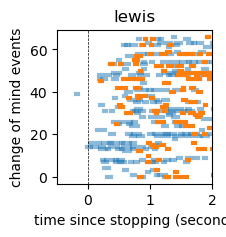

In [12]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/'
if animal == "klein":
    xlim = [-3,4]
else:
    xlim = [-0.5,2]

output_path = os.path.join(output_folder,f"{animal}_{parameter_name_long_theta}_{parameter_name_remote}_figure3C")
with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)
    print(f"Data successfully loaded from {output_path}")
        
(event_intervals, long_theta_intervals, event_info) = loaded_data["event_intervals"], loaded_data["long_theta_intervals"], loaded_data["event_info"]
    
fig, axes = plt.subplots(1,1,figsize = (2, 2))

for event in long_theta_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C0', alpha = 0.5, linewidth = 3)
    
for event in event_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C1', linewidth = 3)


axes.set_ylabel("change of mind events")
axes.set_xlabel("time since stopping (second)")
axes.set_xlim(xlim)
axes.axvline(0,linestyle = "--", color = 'k', linewidth = 0.5)
axes.set_title(animal)


file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
plt.savefig(file_path + f'time_course_event_by_event{animal}.pdf',bbox_inches='tight')
plt.savefig(file_path + f'time_course_event_by_event{animal}.png',bbox_inches='tight')


### delta_t of the first remote minus the first local

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/eliot_params_both_max_segment_run_time_2_state_params_both_max_run_time_2_state_figure3C
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/julio_params_both_max_segment_run_time_2_state_params_both_max_run_time_2_state_figure3C
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/lewis_params_both_max_segment_run_time_2_state_params_both_max_run_time_2_state_figure3C
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/klein_params_both_max_segment_run_time_2_state_params_both_max_run_time_2_state_figure3C


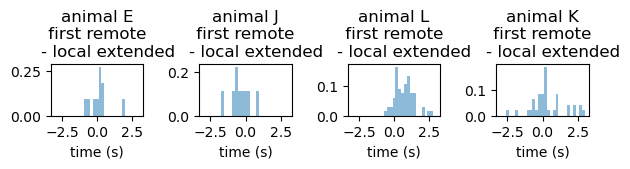

In [16]:
animals = ["eliot","julio","lewis","klein"]
fig, axes = plt.subplots(1,len(animals), figsize=(6, 1.8))

animal_ind = 0
for animal in animals:
    output_path = os.path.join(output_folder,f"{animal}_{parameter_name_long_theta}_{parameter_name_remote}_figure3C")
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")
            
    (event_intervals, long_theta_intervals, event_info) = loaded_data["event_intervals"], loaded_data["long_theta_intervals"], loaded_data["event_info"]
     
    # first find the event indices
    eventIDs = np.unique([_[0] for _ in long_theta_intervals])
    delta_t = []
    for eventID in eventIDs:
        long_intervals = [_[1][0] for _ in long_theta_intervals if _[0] == eventID]
        remote_intervals = [_[1][0] for _ in event_intervals if _[0] == eventID]
        delta_t.append(remote_intervals[0] - long_intervals[0])

    axes[animal_ind].hist(delta_t, alpha = 0.5, weights = np.ones_like(delta_t)/len(delta_t), bins = np.linspace(-3,3,30))
    axes[animal_ind].set_xlabel("time (s)")
    axes[animal_ind].set_title(f"animal {animal[0].upper()}\n first remote \n    - local extended")
    animal_ind += 1
plt.tight_layout()

### triggered histogram

In [66]:
def std_error_proportion(p,N):
    return np.sqrt(p*(1-p)/N)

In [67]:
interval_to_consider = np.arange(-2,2,0.04)

all_events = np.unique([e[0] for e in event_intervals])

remote_counter = np.zeros_like(interval_to_consider)
longtheta_counter = np.zeros_like(interval_to_consider)

t0t1 = None
for eventID in all_events:
    # find all remote events with that eventID
    remote_events = [e for e in event_intervals if e[0] == eventID]

    # find all long theta with that eventID
    long_theta_events = [e for e in long_theta_intervals if e[0] == eventID]

    t0 = long_theta_events[0][1][0]

    # for each event align by t0
    for event in remote_events:

        t0t1 = event[1]
        
        times = np.arange(t0t1[0], t0t1[1], 0.01)# - t0
        bins = np.digitize(times, interval_to_consider)
        remote_counter[bins-1] += 1

    for event in long_theta_events:

        t0t1 = event[1]
        #print(t0t1)
        times = np.arange(t0t1[0], t0t1[1], 0.01)# - t0
        bins = np.digitize(times, interval_to_consider)
        longtheta_counter[bins-1] += 1
        
remote_counter = remote_counter / len(all_events)
longtheta_counter = longtheta_counter / len(all_events)
N = len(all_events)
sd_error_remote_counter = std_error_proportion(remote_counter, N)
sd_error_longtheta_counter = std_error_proportion(longtheta_counter, N)

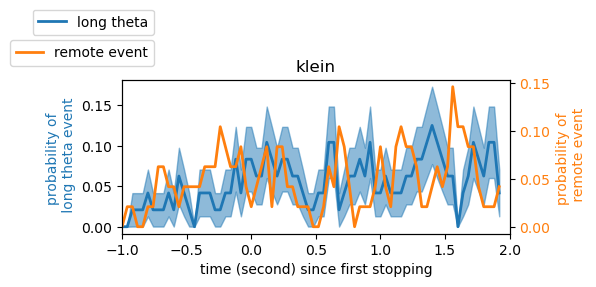

In [68]:
fig, ax1 = plt.subplots(1,1,figsize = (5, 2))

x = interval_to_consider[:-1]
y = np.clip(longtheta_counter[:-1],0,1)
yerr = sd_error_longtheta_counter[:-1]
ax1.plot(x, y, color = 'C0', linewidth = 2, label = 'long theta')
ax1.fill_between(x, y - yerr, y + yerr, color = 'C0', alpha = 0.5)

ax1.set_xlabel("time (second) since first stopping")
ax1.set_ylabel("probability of \n long theta event",color='C0')

ax2 = ax1.twinx()
ax2.plot(interval_to_consider[:-1], remote_counter[:-1], color = 'C1', linewidth = 2, label = 'remote event')
ax2.set_ylabel('probability of \n remote event', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#ax1.set_ylim([0,1])
ax1.set_xlim([-1,2])
ax2.set_xlim([-1,2])
#ax2.set_ylim([0,1])
ax1.legend(bbox_to_anchor=(0.1, 1.5))
ax2.legend(bbox_to_anchor=(0.1, 1.3))
ax1.set_title(animal)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/"
plt.savefig(file_path + f'average_time_course_event_by_event{animal}.pdf',bbox_inches='tight')
plt.savefig(file_path + f'average_time_course_event_by_event{animal}.png',bbox_inches='tight')

### Home versus outer well

In [172]:
success = {}
for animal in ["molly", "eliot","julio", "klein", "lewis"]:
    (remote_intervals, remote_interval_identities,
     remote_max_distance, remote_time_spent, contain_long_theta,
     remote_trial_infos) = return_remote_intervals(animal, list_of_days_animals[animal],
                                                                    remote_flag = True)

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_{animal}'
    data = {"remote_intervals": remote_intervals, "remote_interval_identities": remote_interval_identities,
           "remote_max_distance":remote_max_distance,
            "remote_time_spent": remote_time_spent,
            "contain_long_theta": contain_long_theta,
            "remote_trial_infos": remote_trial_infos}
    file_path = output_folder + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1

molly20220416_.nwb


[2026-04-01 08:52:53,237][WARNING]: Skipped checksum for file with hash: 332d67b8-c51d-a832-6c89-43be386cb0bf, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_LKDRWQDXB3.nwb
[2026-04-01 08:53:02,629][WARNING]: Skipped checksum for file with hash: 5de8fe3f-edf8-d8d0-6284-1feeb842fc61, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_FHQXSE63O4.nwb


molly20220417_.nwb


[2026-04-01 08:53:11,618][WARNING]: Skipped checksum for file with hash: 626aaecd-269e-6d46-db1c-0103d34232fe, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_IRQFDMOWQJ.nwb
[2026-04-01 08:53:20,685][WARNING]: Skipped checksum for file with hash: abfd4b4e-11b4-10b0-e5aa-2cfa60e059d0, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_G5EMH517VO.nwb
[2026-04-01 08:53:29,590][WARNING]: Skipped checksum for file with hash: 4250dd24-0691-5ecb-b54b-ff5a09d7bcf2, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_SXTFYNKTIJ.nwb
[2026-04-01 08:53:38,534][WARNING]: Skipped checksum for file with hash: 67675c8f-b915-5a90-9369-6c355772f279, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_TFP22K3E96.nwb
[2026-04-01 08:53:47,439][WARNING]: Skipped checksum for file with hash: d537084f-8ecf-63c2-bb2e-6217dbfb1c5d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_BDKPBDQGLW.nwb


molly20220418_.nwb


...

lewis20240109_.nwb


[2026-04-01 09:13:29,645][WARNING]: Skipped checksum for file with hash: 36d34e88-b864-7573-beac-3eb1cc465429, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_H4OG51M5OZ.nwb
[2026-04-01 09:13:38,565][WARNING]: Skipped checksum for file with hash: 290b796b-fad8-514a-ead5-49e55ad68bbb, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_Q2UIPMBMDE.nwb
[2026-04-01 09:13:47,474][WARNING]: Skipped checksum for file with hash: 56da3799-1a9a-dd79-c87f-f0ef7f4140d8, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_TKAANSPE0B.nwb
[2026-04-01 09:13:56,440][WARNING]: Skipped checksum for file with hash: e7e24ce4-9490-584b-bcb5-69a9db83db90, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_E4A4J3FZDY.nwb


lewis20240110_.nwb


[2026-04-01 09:14:05,594][WARNING]: Skipped checksum for file with hash: 08ffacf2-9095-893f-e0ee-25b218894533, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_3FL3YYWVDS.nwb
[2026-04-01 09:14:14,713][WARNING]: Skipped checksum for file with hash: f81ce41f-f0df-7409-5311-f8195fff399e, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_MV2ZHR9MTI.nwb
[2026-04-01 09:14:23,847][WARNING]: Skipped checksum for file with hash: 3deb5ee3-e8c3-e10c-157a-794e2c3befdb, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_WJFD5O52GF.nwb
[2026-04-01 09:14:33,066][WARNING]: Skipped checksum for file with hash: 163aef8a-114c-c68f-4360-f5b33ee12643, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_MXPX7HR6DI.nwb


data saved to /stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_lewis.pkl


In [173]:
success

{'molly': 1, 'eliot': 1, 'julio': 1, 'klein': 1, 'lewis': 1}

In [151]:
### GLM to predict length max proportion with the existence of home or nonhome remote events

In [175]:
remote_max_distance = {}
remote_intervals = {}
remote_interval_identities = {}
time_spent = {}
contain_long_theta = {}
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/home_arm_remote_{animal}'
    file_path = output_folder + '.pkl'

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    remote_max_distance[animal] = data["remote_max_distance"]
    remote_intervals[animal] = data["remote_intervals"]
    remote_interval_identities[animal] = data["remote_interval_identities"]
    time_spent[animal] = data["remote_time_spent"]
    contain_long_theta[animal] = data["contain_long_theta"]
    

In [180]:
ols_model, ols_result1 = GLM_max_proportion(time_spent, remote_intervals, remote_interval_identities)

In [181]:
print(ols_result1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     11.89
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.43e-10
Time:                        09:36:59   Log-Likelihood:                -591.73
No. Observations:                 329   AIC:                             1195.
Df Residuals:                     323   BIC:                             1218.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.0561      0.099     20.865   

0.8800000000000001 0.03


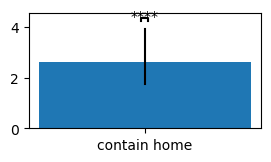

In [161]:
fig, ax1 = plt.subplots(1, 1, figsize=(3, 1.5),
                               #gridspec_kw={'height_ratios': [0.1,0.5]},
                               sharex = True)
#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

ax1.bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    ax1.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = ax1, color = 'k')

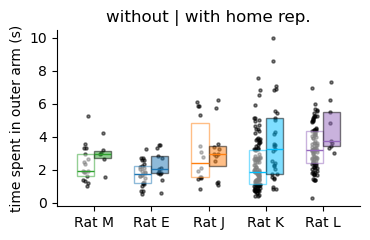

In [182]:
violin_plot(remote_intervals, remote_interval_identities, time_spent)

### intersection with long theta events for remote events without home | remote events of home

In [191]:
from spyglass.shijiegu.changeOfMind import color_by_rat

In [192]:
color_by_rat

{'eliot': 'C0',
 'molly': 'C2',
 'lewis': 'C4',
 'julio': 'C1',
 'klein': 'deepskyblue'}

Text(0.5, 1.0, 'home rep. AND  local extended |  arm rep. AND local extended')

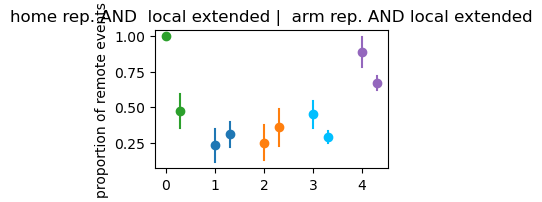

In [202]:
animal_ind = 0
dx = 0.3

fig, axes = plt.subplots(1,1, figsize=(3, 1.8))
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    contain_home, _ = return_meta_data(remote_intervals[animal], remote_interval_identities[animal])
    contain_long = contain_long_theta[animal]

    contain_home = np.array(contain_home)
    contain_long = np.array(contain_long)
    
    #data1 = np.logical_and(contain_home > 0, contain_long > 0)#contain_long[contain_home]
    #data2 = np.logical_and(contain_home == 0, contain_long > 0)
    data1 = contain_long[contain_home]
    data2 = contain_long[~contain_home]
    m1, mu1 = np.mean(data1), np.std(data1)/np.sqrt(len(data1))
    m2, mu2 = np.mean(data2), np.std(data2)/np.sqrt(len(data2))

    x1 = animal_ind
    x2 = animal_ind + dx
    axes.scatter([x1,x2], [m1, m2], color = color_by_rat[animal])
    axes.plot([x1,x1], [m1-mu1, m1+mu1], color = color_by_rat[animal])
    axes.plot([x2,x2], [m2-mu2, m2+mu2], color = color_by_rat[animal])

    animal_ind += 1

axes.set_ylabel("proportion of remote events")
axes.set_title("home rep. AND  local extended |  arm rep. AND local extended")

In [189]:
np.mean()

0.8888888888888888

In [190]:
np.mean(contain_long[~contain_home])

0.6666666666666666

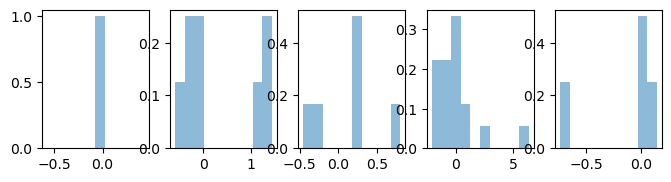

In [39]:
animals = ["molly", "eliot", "julio", "klein", "lewis"]
fig, axes = plt.subplots(1,len(animals), figsize=(8, 1.8))

animal_ind = 0
for animal in animals:
    _, delta_t = return_meta_data(remote_intervals[animal], remote_interval_identities[animal])
    data1 = delta_t
    axes[animal_ind].hist(data1, alpha = 0.5, weights = np.ones_like(data1)/len(data1)) 
    animal_ind += 1

# End

In [22]:
interval_to_consider = np.arange(-2,2,0.04)

all_events = np.unique([e[0] for e in event_intervals])

remote_counter = np.zeros_like(interval_to_consider)
longtheta_counter = np.zeros_like(interval_to_consider)

t0t1 = None
for eventID in all_events:
    # find all remote events with that eventID
    remote_events = [e for e in event_intervals if e[0] == eventID]

    # find all long theta with that eventID
    long_theta_events = [e for e in long_theta_intervals if e[0] == eventID]

    t0 = remote_events[0][1][0]

    # for each event align by t0
    for event in remote_events:

        t0t1 = event[1]
        
        times = np.arange(t0t1[0], t0t1[1], 0.01) - t0
        bins = np.digitize(times, interval_to_consider)
        remote_counter[bins-1] += 1

    for event in long_theta_events:

        t0t1 = event[1]
        #print(t0t1)
        times = np.arange(t0t1[0], t0t1[1], 0.01) - t0
        bins = np.digitize(times, interval_to_consider)
        longtheta_counter[bins-1] += 1
        
remote_counter = remote_counter / len(all_events)
longtheta_counter = longtheta_counter / len(all_events)
N = len(all_events)
sd_error_remote_counter = std_error_proportion(remote_counter, N)
sd_error_longtheta_counter = std_error_proportion(longtheta_counter, N)

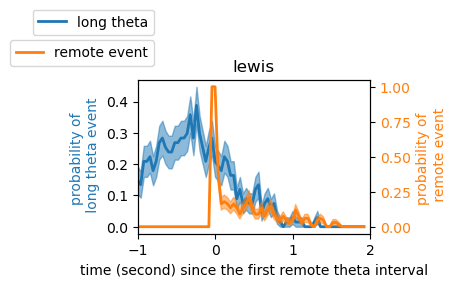

In [23]:
fig, ax1 = plt.subplots(1,1,figsize = (3, 2))
x = interval_to_consider[:-1]
y = np.clip(longtheta_counter[:-1],0,1)
yerr = sd_error_longtheta_counter[:-1]

ax1.plot(x, y,  color = 'C0', linewidth = 2, label = 'long theta')
ax1.fill_between(x, y - yerr, y + yerr, color = 'C0', alpha = 0.5)

ax1.set_xlabel("time (second) since the first remote theta interval")
ax1.set_ylabel("probability of \n long theta event",color='C0')

ax2 = ax1.twinx()

y = np.clip(remote_counter[:-1],0,1)
yerr = sd_error_remote_counter[:-1]

ax2.plot(x, y, color = 'C1', linewidth = 2, label = 'remote event')
ax2.fill_between(x, y - yerr, y + yerr, color = 'C1', alpha = 0.5)
ax2.set_ylabel('probability of \n remote event', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_xlim([-1,2])
ax2.set_xlim([-1,2])
#ax2.set_ylim([0,1])
ax1.legend(bbox_to_anchor=(0.1, 1.5))
ax2.legend(bbox_to_anchor=(0.1, 1.3))
ax1.set_title(animal)

plt.savefig(f'theta_time_course_{animal}.pdf',dpi=300,bbox_inches='tight')

# End here

## investigate remote events - start

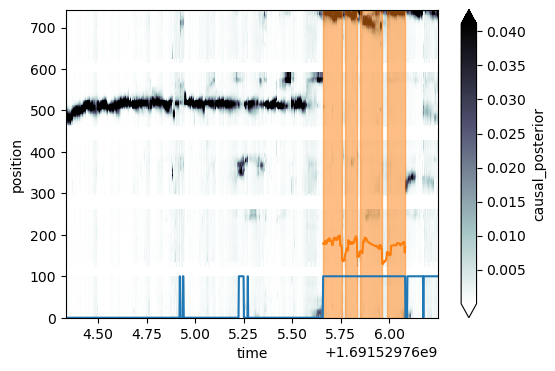

In [443]:
fig, axes = plt.subplots(1,1,figsize = (6, 4))


posterior_position_subset.plot(x='time', y='position', ax=axes, rasterized=True, robust=True, cmap='bone_r')
axes.plot(position1d_subset.time, is_remote*100)
axes.plot(decode_subset_.time, 100 + state_subset[:,0]*100)

# 2. find max decode location during that interval
for sg in snippets:
    axes.axvspan(sg[0],sg[1],color = 'C1',alpha = 0.5)

In [376]:
position1d_subset

,time,linear_position,track_segment_id,projected_x_position,projected_y_position
343637,1.691530e+09,1.773974,0.0,210.373109,232.230303
343638,1.691530e+09,1.773974,0.0,210.373109,232.230303
343639,1.691530e+09,1.773974,0.0,210.373109,232.230303
343640,1.691530e+09,1.773974,0.0,210.373109,232.230303
343641,1.691530e+09,1.773974,0.0,210.373109,232.230303
...,...,...,...,...,...
347540,1.691530e+09,664.499573,9.0,239.848965,145.039916
347541,1.691530e+09,664.534985,9.0,239.880823,145.024454
347542,1.691530e+09,664.570397,9.0,239.912681,145.008992
347543,1.691530e+09,664.599457,9.0,239.938824,144.996303


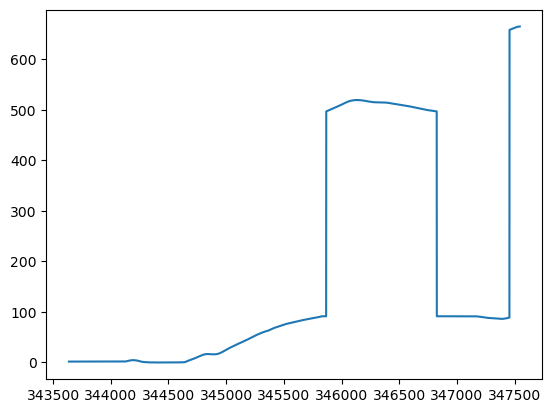

In [377]:
plt.plot(position1d_subset.linear_position)

0.09599995613098145
0.06200003623962402
0.11399984359741211
0.09400010108947754
0.029999971389770508


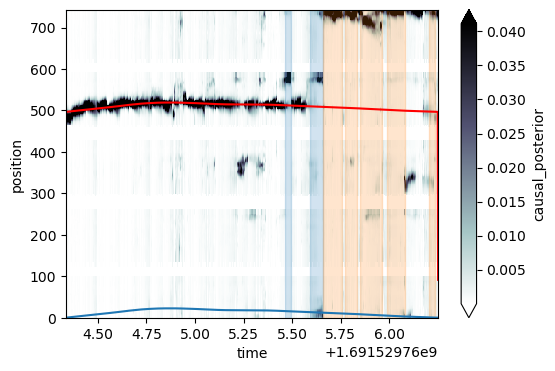

In [467]:
fig, axes = plt.subplots(1,1,figsize = (6, 4))

t0,t1 = positions.index[0], positions.index[-1]
decode_subset = select_subset_helper(decode,(t0,t1))
posterior_position_subset = decode_subset.causal_posterior.sum(dim='state') #causal decoder

posterior_position_subset.plot(x='time', y='position', ax=axes, rasterized=True, robust=True, cmap='bone_r')
# 2. find max decode location during that interval
posterior_position_subset = decode_subset.causal_posterior.sum(dim='state') #causal decoder

plt.plot(positions)
plt.plot(triggered_position, color = 'r')
for intvl in interval_long_theta:
    plt.axvspan(intvl[0],intvl[1],color = 'C0',alpha = 0.2)
for intvl in interval_remote:
    print(intvl[1]-intvl[0])
    plt.axvspan(intvl[0],intvl[1],color = 'C1',alpha = 0.2)

## investigate remote events - end

In [500]:
#list_of_days_animals

In [502]:
success

{'lewis': 1, 'julio': 1, 'klein': 1}

In [37]:
animal = "klein"

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/klein_figure4G


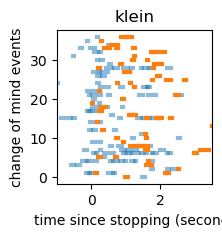

In [38]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/'

output_path = os.path.join(output_folder,f"{animal}_figure4G") #os.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)
    print(f"Data successfully loaded from {output_path}")
        
(event_intervals, long_theta_intervals, event_info) = loaded_data["event_intervals"], loaded_data["long_theta_intervals"], loaded_data["event_info"]
    
fig, axes = plt.subplots(1,1,figsize = (2, 2))

for event in long_theta_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C0', alpha = 0.5, linewidth = 3)
    
for event in event_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C1', linewidth = 3)


axes.set_ylabel("change of mind events")
axes.set_xlabel("time since stopping (second)")
axes.set_xlim([-1,3.5])
axes.set_title(animal)

plt.savefig(f'time_course_event_by_event{animal}.pdf',dpi=300,bbox_inches='tight')

### remote triggered histogram

In [39]:
interval_to_consider = np.arange(-2,2,0.04)

all_events = np.unique([e[0] for e in event_intervals])

remote_counter = np.zeros_like(interval_to_consider)
longtheta_counter = np.zeros_like(interval_to_consider)

t0t1 = None
for eventID in all_events:
    # find all remote events with that eventID
    remote_events = [e for e in event_intervals if e[0] == eventID]

    # find all long theta with that eventID
    long_theta_events = [e for e in long_theta_intervals if e[0] == eventID]

    t0 = long_theta_events[0][1][0]

    # for each event align by t0
    for event in remote_events:

        t0t1 = event[1]
        
        times = np.arange(t0t1[0], t0t1[1], 0.01)# - t0
        bins = np.digitize(times, interval_to_consider)
        remote_counter[bins-1] += 1

    for event in long_theta_events:

        t0t1 = event[1]
        #print(t0t1)
        times = np.arange(t0t1[0], t0t1[1], 0.01)# - t0
        bins = np.digitize(times, interval_to_consider)
        longtheta_counter[bins-1] += 1
        
remote_counter = remote_counter / len(all_events)
longtheta_counter = longtheta_counter / len(all_events)

Text(0.5, 1.0, 'klein')

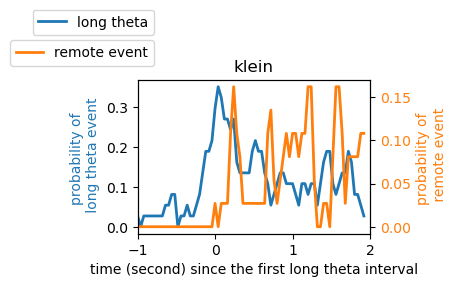

In [40]:
fig, ax1 = plt.subplots(1,1,figsize = (3, 2))
ax1.plot(interval_to_consider[:-1], np.clip(longtheta_counter[:-1],0,1),  color = 'C0', linewidth = 2, label = 'long theta')

ax1.set_xlabel("time (second) since the first long theta interval")
ax1.set_ylabel("probability of \n long theta event",color='C0')

ax2 = ax1.twinx()
ax2.plot(interval_to_consider[:-1], remote_counter[:-1], color = 'C1', linewidth = 2, label = 'remote event')
ax2.set_ylabel('probability of \n remote event', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#ax1.set_ylim([0,1])
ax1.set_xlim([-1,2])
ax2.set_xlim([-1,2])
#ax2.set_ylim([0,1])
ax1.legend(bbox_to_anchor=(0.1, 1.5))
ax2.legend(bbox_to_anchor=(0.1, 1.3))
ax1.set_title(animal)

In [41]:
def std_error_proportion(p,N):
    return np.sqrt(p*(1-p)/N)

In [42]:
interval_to_consider = np.arange(-2,2,0.04)

all_events = np.unique([e[0] for e in event_intervals])

remote_counter = np.zeros_like(interval_to_consider)
longtheta_counter = np.zeros_like(interval_to_consider)

t0t1 = None
for eventID in all_events:
    # find all remote events with that eventID
    remote_events = [e for e in event_intervals if e[0] == eventID]

    # find all long theta with that eventID
    long_theta_events = [e for e in long_theta_intervals if e[0] == eventID]

    t0 = remote_events[0][1][0]

    # for each event align by t0
    for event in remote_events:

        t0t1 = event[1]
        
        times = np.arange(t0t1[0], t0t1[1], 0.01) - t0
        bins = np.digitize(times, interval_to_consider)
        remote_counter[bins-1] += 1

    for event in long_theta_events:

        t0t1 = event[1]
        #print(t0t1)
        times = np.arange(t0t1[0], t0t1[1], 0.01) - t0
        bins = np.digitize(times, interval_to_consider)
        longtheta_counter[bins-1] += 1
        
remote_counter = remote_counter / len(all_events)
longtheta_counter = longtheta_counter / len(all_events)
N = len(all_events)
sd_error_remote_counter = std_error_proportion(remote_counter, N)
sd_error_longtheta_counter = std_error_proportion(longtheta_counter, N)

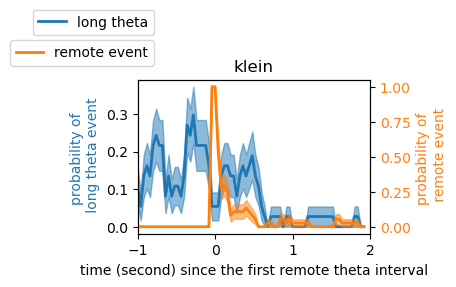

In [43]:
fig, ax1 = plt.subplots(1,1,figsize = (3, 2))
x = interval_to_consider[:-1]
y = np.clip(longtheta_counter[:-1],0,1)
yerr = sd_error_longtheta_counter[:-1]

ax1.plot(x, y,  color = 'C0', linewidth = 2, label = 'long theta')
ax1.fill_between(x, y - yerr, y + yerr, color = 'C0', alpha = 0.5)

ax1.set_xlabel("time (second) since the first remote theta interval")
ax1.set_ylabel("probability of \n long theta event",color='C0')

ax2 = ax1.twinx()

y = np.clip(remote_counter[:-1],0,1)
yerr = sd_error_remote_counter[:-1]

ax2.plot(x, y, color = 'C1', linewidth = 2, label = 'remote event')
ax2.fill_between(x, y - yerr, y + yerr, color = 'C1', alpha = 0.5)
ax2.set_ylabel('probability of \n remote event', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

ax1.set_xlim([-1,2])
ax2.set_xlim([-1,2])
#ax2.set_ylim([0,1])
ax1.legend(bbox_to_anchor=(0.1, 1.5))
ax2.legend(bbox_to_anchor=(0.1, 1.3))
ax1.set_title(animal)

plt.savefig(f'theta_time_course_{animal}.pdf',dpi=300,bbox_inches='tight')

In [78]:
long_theta_interval

[(0, array([0.26799989, 0.68400002])),
 (0, array([0.74799967, 0.85999942])),
 (1, array([0.25199962, 0.32199979])),
 (1, array([0.37799978, 0.4599998 ])),
 (1, array([0.59599972, 0.76199985])),
 (1, array([0.79399967, 0.87399983])),
 (1, array([1.04999924, 1.09399962])),
 (2, array([0.23799992, 0.32399988])),
 (2, array([2.28399897, 2.52799892])),
 (2, array([2.55399895, 2.61199903])),
 (2, array([2.63799906, 2.7519989 ])),
 (2, array([3.32799864, 3.40599871])),
 (2, array([0.23799992, 0.32399988])),
 (2, array([2.28399897, 2.52799892])),
 (2, array([2.55399895, 2.61199903])),
 (2, array([2.63799906, 2.7519989 ])),
 (2, array([3.32799864, 3.40599871])),
 (3, array([0.23799992, 0.32399988])),
 (3, array([2.28399897, 2.52799892])),
 (3, array([2.55399895, 2.61199903])),
 (3, array([2.63799906, 2.7519989 ])),
 (3, array([3.32799864, 3.40599871])),
 (3, array([0.23799992, 0.32399988])),
 (3, array([2.28399897, 2.52799892])),
 (3, array([2.55399895, 2.61199903])),
 (3, array([2.63799906, 2

### End here

In [45]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = 0.1, use_1d = 1)

remote_info, remote_time_intervals = loaded_data['info_animal'], loaded_data['time_intervals_animal']

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


In [59]:
remote_time_intervals[2][0][-1]

1704481574.316091

In [60]:
remote_time_intervals[3][0][-1]

1704481574.316091

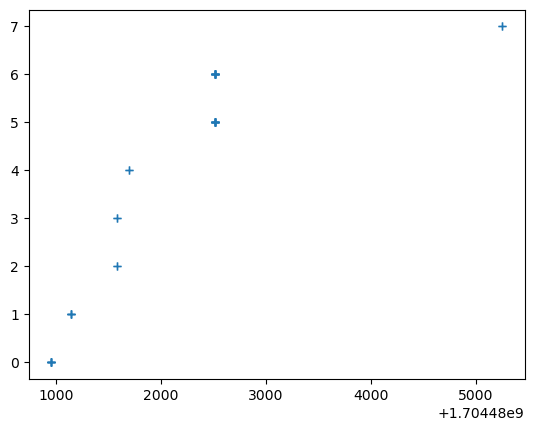

In [54]:
ind = 0
for intervals in remote_time_intervals[:8]:
    for interval in intervals:
        x = interval
        y = ind
        plt.plot(x, [y, y], '+', color = 'C0')
    ind += 1

In [62]:
paramters = {"proportion": 0.1,
             "delta_t_minus":5, "delta_t_plus":5,
             "max_flag":1, "segment_only": False,
             "multiple_CoM":1, "single_CoM":1, "first_CoM":0,
             "control": 0}
        
loaded_data = load_triggered_position_decode_day(animal, list_of_days_animals[animal][0], encoding_set_animals[animal],
                                                 classifier_param_name_animals[animal],
                                                 **paramters)

triggered_positions, triggered_positions_abs, triggered_trial_infos = (
                    loaded_data["triggered_positions_baseoff"],
                    loaded_data["triggered_positions"],
                    loaded_data["triggered_trial_info"])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control0_allposterior.pkl':


In [64]:
triggered_positions[0]

time
1.704480e+09      1.891575
1.704480e+09      1.891706
1.704480e+09      1.891838
1.704480e+09      1.891969
1.704480e+09      1.892101
                   ...    
1.704480e+09    418.292280
1.704480e+09    418.292280
1.704480e+09    418.292280
1.704480e+09    418.292280
1.704480e+09    418.292280
Length: 5001, dtype: float64

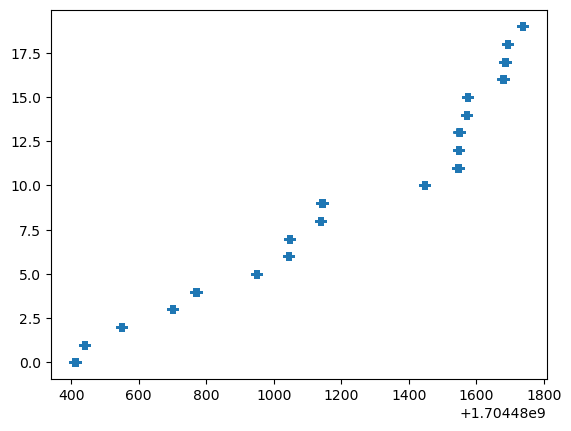

In [72]:
ind = 0
for intervals in triggered_positions[:20]:
    interval = intervals.index
    x = interval
    y = ind + np.zeros_like(interval)
    plt.plot(x, y, '+', color = 'C0')
    ind += 1

In [75]:
ind1 = 8
ind2 = 9
print(triggered_positions[ind1].index[0],triggered_positions[ind1].index[-1])
print(triggered_positions[ind2].index[0],triggered_positions[ind2].index[-1])

1704481133.1982584 1704481143.1982546
1704481137.3222568 1704481147.322253


In [73]:
triggered_positions[9].index[0]

1704481137.3222568

[15:47:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:47:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Text(0.5, 1.0, 'lewis')

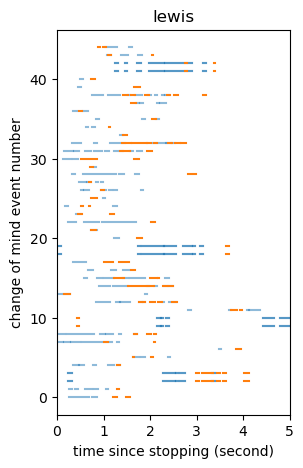

In [41]:
fig, axes = plt.subplots(1,1,figsize = (3, 5))

for event in long_theta_interval:
    y, x = event
    axes.plot(x,[y,y], color = 'C0', alpha = 0.5)
    
for event in event_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C1')


axes.set_ylabel("change of mind event number")
axes.set_xlabel("time since stopping (second)")
axes.set_xlim([0,5])
axes.set_title(animal)

(0.0, 5.0)

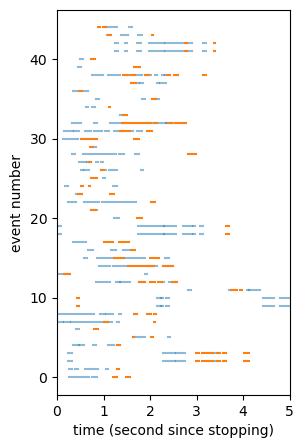

In [37]:
fig, axes = plt.subplots(1,1,figsize = (3, 5))

for event in long_theta_interval:
    y, x = event
    axes.plot(x,[y,y], color = 'C0', alpha = 0.5)
    
for event in event_intervals:
    y, x = event
    axes.plot(x,[y,y], color = 'C1')


axes.set_ylabel("change of mind event number")
axes.set_xlabel("time since stopping (second)")
axes.set_xlim([0,5])
axes.set_title(animal)